# TP 3  : Graph Neural Networks Architecture

**Théo Rudkiewicz, Cyriaque Rousselot**

# TUTORIAL

### Install Pytorch Geometric

To handle graph data, we use the library Pytorch Geometric : https://pytorch-geometric.readthedocs.io/en/latest/

*   If you use _Google Colab_, simply run the following cell to install Pytorch Geometric (**advised**).
*   If you plan using your _own environment_, follow the documentation to install Pytorch Geometric : https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html and skip the following cell.

In [ ]:
########## INSTALL TORCH GEOMETRIC ##################
# https://pytorch-geometric.readthedocs.io/en/latest/
#####################################################
import torch


def format_pytorch_version(version):
    return version.split("+")[0]


TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)


def format_cuda_version(version):
    return "cu" + version.replace(".", "")


CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)

!pip install torch-scatter     -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse      -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-cluster     -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-spline-conv -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric


Looking in links: https://pytorch-geometric.com/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 7.7 MB/s eta 0:00:00
Looking in links: https://pytorch-geometric.com/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 19.2 MB/s eta 0:00:00
Looking in links: https://pytorch-geometric.com/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 45.2 MB/s eta 0:00:00
Looking in links: https://pytorch-geometric.com/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.6 MB/s eta 0:00:00


### Import required packages

Run the following cell to import all required packages. This cell **must not** be modified.

To significantly accelerate your training, it is advised to use GPU. Using Google Colab, you need to activate it :

*   Edit --> Notebook Setting --> Hardware accelerator --> GPU

In [ ]:
#####################################################
################## PACKAGES #########################
#####################################################
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch_geometric.nn as graphnn
from sklearn.metrics import f1_score
from torch_geometric.datasets import PPI
from torch_geometric.loader import DataLoader
import torch.nn.functional as F

### Dataset

We use the Protein-Protein Interaction (PPI) network dataset which includes:
- 20 graphs for training
- 2 graphs for validation
- 2 graphs for testing

One graph of the PPI dataset has on average 2372 nodes. Each node has:
- 50 features : positional gene sets / motif gene / immunological signatures ...
- 121 (binary) labels : gene ontology sets (way to classify gene products like proteins).

**This problem aims to predict, for a given PPI graph, the correct nodes' labels**.

**It is a node (multi-label) classification task** (trained using supervised learning, with labels to be predicted for each node).

For your curiosity, more detailed information on the dataset and some applications:
- https://cs.stanford.edu/~jure/pubs/pathways-psb18.pdf
- https://arxiv.org/abs/1707.04638

To understand how a graph data is implemented in Pytorch Geometric, refer to : https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html


In [ ]:
### LOAD DATASETS

BATCH_SIZE = 2

# Train Dataset
train_dataset = PPI(root="", split="train")
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
# Val Dataset
val_dataset = PPI(root="", split="val")
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
# Test Dataset
test_dataset = PPI(root="", split="test")
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Number of features and classes
n_features, n_classes = train_dataset[0].x.shape[1], train_dataset[0].y.shape[1]

print("Number of samples in the train dataset: ", len(train_dataset))
print("Number of samples in the val dataset: ", len(test_dataset))
print("Number of samples in the test dataset: ", len(test_dataset))
print("Output of one sample from the train dataset: ", train_dataset[0])
print("Edge_index :")
print(train_dataset[0].edge_index)
print("Number of features per node: ", n_features)
print("Number of classes per node: ", n_classes)

Extracting ./ppi.zip
Processing...
/usr/local/lib/python3.11/dist-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Number of samples in the train dataset:  20
Number of samples in the val dataset:  2
Number of samples in the test dataset:  2
Output of one sample from the train dataset:  Data(x=[1767, 50], edge_index=[2, 32318], y=[1767, 121])
Edge_index :
tensor([[   0,    0,    0,  ..., 1744, 1745, 1749],
        [ 372, 1101,  766,  ..., 1745, 1744, 1739]])
Number of features per node:  50
Number of classes per node:  121


Done!


### Define a basic Model

Here we define a very simple Graph Neural Network model which will be used as our baseline. This model consists of three graph convolutional layers (from https://arxiv.org/pdf/1609.02907.pdf). The first two layers computes 256 features, followed by an ELU activation function. The last layer is used for (multi-label) classification task, computing 121 features (for each node).

In [ ]:
#####################################################
################## MODEL ############################
#####################################################
class BasicGraphModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.graphconv1 = graphnn.GCNConv(input_size, hidden_size)
        self.graphconv2 = graphnn.GCNConv(hidden_size, hidden_size)
        self.graphconv3 = graphnn.GCNConv(hidden_size, output_size)

        self.elu = nn.ELU()

    def forward(self, x, edge_index):
        x = self.graphconv1(x, edge_index)
        x = self.elu(x)
        x = self.graphconv2(x, edge_index)
        x = self.elu(x)
        x = self.graphconv3(x, edge_index)

        return x

Next function is designed to evaluate the performance of the model, computing the F1-Score

In [ ]:
#####################################################
############### TEST FUNCTION #######################
#####################################################
def evaluate(model, loss_fcn, device, dataloader):
    score_list_batch = []

    model.eval()
    for i, batch in enumerate(dataloader):
        batch = batch.to(device)
        output = model(batch.x, batch.edge_index)
        loss_test = loss_fcn(output, batch.y)
        predict = np.where(output.detach().cpu().numpy() >= 0, 1, 0)
        score = f1_score(batch.y.cpu().numpy(), predict, average="micro")
        score_list_batch.append(score)

    return np.array(score_list_batch).mean()

Next we construct the function to train the model.

In [ ]:
#####################################################
############## TRAIN FUNCTION #######################
#####################################################
def train(model, loss_fcn, device, optimizer, max_epochs, train_dataloader, val_dataloader):
    epoch_list = []
    scores_list = []

    # loop over epochs
    for epoch in range(max_epochs):
        model.train()
        losses = []
        # loop over batches
        for i, train_batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            train_batch_device = train_batch.to(device)
            # logits is the output of the model
            logits = model(train_batch_device.x, train_batch_device.edge_index)
            # compute the loss
            loss = loss_fcn(logits, train_batch_device.y)
            # optimizer step
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        loss_data = np.array(losses).mean()
        print("Epoch {:05d} | Loss: {:.4f}".format(epoch + 1, loss_data))

        if epoch % 5 == 0:
            # evaluate the model on the validation set
            # computes the f1-score (see next function)
            score = evaluate(model, loss_fcn, device, val_dataloader)
            print("F1-Score: {:.4f}".format(score))
            scores_list.append(score)
            epoch_list.append(epoch)

    return epoch_list, scores_list

Let's train this model !

In [ ]:
### DEVICE GPU OR CPU : will select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice: ", device)

### Max number of epochs
max_epochs = 200

### DEFINE THE MODEL
basic_model = BasicGraphModel(input_size=n_features, hidden_size=256, output_size=n_classes).to(
    device
)

### DEFINE LOSS FUNCTION
loss_fcn = nn.BCEWithLogitsLoss()

### DEFINE OPTIMIZER
optimizer = torch.optim.Adam(basic_model.parameters(), lr=0.005)

### TRAIN THE MODEL
epoch_list, basic_model_scores = train(
    basic_model,
    loss_fcn,
    device,
    optimizer,
    max_epochs,
    train_dataloader,
    val_dataloader,
)


Device:  cpu
Epoch 00001 | Loss: 0.6369
F1-Score: 0.4563
Epoch 00002 | Loss: 0.5803
Epoch 00003 | Loss: 0.5623
Epoch 00004 | Loss: 0.5553
Epoch 00005 | Loss: 0.5507
Epoch 00006 | Loss: 0.5458
F1-Score: 0.5147
Epoch 00007 | Loss: 0.5423
Epoch 00008 | Loss: 0.5384
Epoch 00009 | Loss: 0.5343
Epoch 00010 | Loss: 0.5312
Epoch 00011 | Loss: 0.5284
F1-Score: 0.5133
Epoch 00012 | Loss: 0.5257
Epoch 00013 | Loss: 0.5233
Epoch 00014 | Loss: 0.5210
Epoch 00015 | Loss: 0.5186
Epoch 00016 | Loss: 0.5163
F1-Score: 0.5324
Epoch 00017 | Loss: 0.5141
Epoch 00018 | Loss: 0.5119
Epoch 00019 | Loss: 0.5097
Epoch 00020 | Loss: 0.5076
Epoch 00021 | Loss: 0.5055
F1-Score: 0.5409
Epoch 00022 | Loss: 0.5035
Epoch 00023 | Loss: 0.5015
Epoch 00024 | Loss: 0.4996
Epoch 00025 | Loss: 0.4977
Epoch 00026 | Loss: 0.4959
F1-Score: 0.5537
Epoch 00027 | Loss: 0.4941
Epoch 00028 | Loss: 0.4923
Epoch 00029 | Loss: 0.4908
Epoch 00030 | Loss: 0.4892
Epoch 00031 | Loss: 0.4880
F1-Score: 0.5566
Epoch 00032 | Loss: 0.4870
Epo

Let's evaluate the performance of this basic model

Basic Model : F1-Score on the validation set: 0.6340


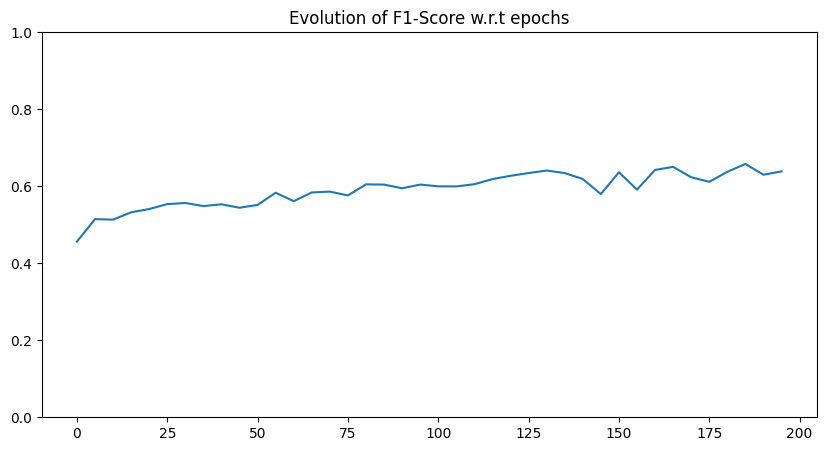

In [ ]:
### F1-SCORE ON VALID DATASET
score_valid = evaluate(basic_model, loss_fcn, device, val_dataloader)
print("Basic Model : F1-Score on the validation set: {:.4f}".format(score_valid))


### PLOT EVOLUTION OF F1-SCORE W.R.T EPOCHS
def plot_f1_score(epoch_list, scores):
    plt.figure(figsize=[10, 5])
    plt.plot(epoch_list, scores)
    plt.title("Evolution of F1-Score w.r.t epochs")
    plt.ylim([0.0, 1.0])
    plt.show()


plot_f1_score(epoch_list, basic_model_scores)

# QUESTIONS

## Grading

You will be graded on 5 questions. You will need to provide at least 4 files :
1. This Notebook
2. `class_model_gnn.py`
3. `model.pth` (the file **must be of size less than 50Mo** but 20Mo should be enough to get a very good model)
4. `conv_as_message_passing.py`

If the function you defined passes all the tests, you will get the full grade. Otherwise we  will look at the intermediate questions in the notebook to give you partial credit.



 Please provide clear, short and __bold font__ answers.  

> Question 1 : Design, build and train a model with a F1-score higher than 93% on validation set (**HINT :** https://arxiv.org/pdf/1710.10903.pdf).


 Provide two files : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a file  `class_model_gnn.py` containing the class inheriting from `torch.nn.Module` architecture of your final model to load
 -  a `model.pth` file : the model weights

 We will  test your model on final F1-Score on a test set. You must not use the test set for hyperparameter training.

Intermediate question :

 Provide the script for training, and a plot of the training loss.  

In [ ]:
class StudentModel(nn.Module):
    def __init__(self):
      super(StudentModel, self).__init__()#attention à l'initialisation de Gloriot
      self.GAT1 = graphnn.conv.GATConv(in_channels = n_features, out_channels = 256, heads = 4, concat = True)
      self.GAT2 = graphnn.conv.GATConv(in_channels = 1024, out_channels = 256, heads = 4, concat=True)
      self.GAT3 = graphnn.conv.GATConv(in_channels = 1024, out_channels = 121, heads = 6, concat=False) #concat = False averages
      self.linear_skip = nn.Linear(1024, 1024)
    #init is defautl Glorot in pytorch

    def forward(self, x, edge_index):
        x = self.GAT1(x, edge_index)
        x = F.elu(x)
        h = self.GAT2(x, edge_index) # skip connection suggested by the article
        x = h + self.linear_skip(x) #tried this to enrich the skip connection but did not yield significant improvement
        x = F.elu(x)
        x = self.GAT3(x, edge_index)
        #no need for sigmoid as automatically computed by the loss
        return x

In [ ]:
#batch_size = 2 is defined withing dataloader at beggining of code
def train_student(model, loss_fcn, device, optimizer, max_epochs, train_dataloader, val_dataloader):
    epoch_list = []
    scores_list = []
    #Early stopping:
    best_val_score = -torch.inf
    patience = 100
    no_improve_epochs = 0
    for epoch in range(max_epochs):
      losses = []
      for i, train_batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        train_batch_device = train_batch.to(device)
        logits = model(train_batch_device.x, train_batch_device.edge_index)
        loss = loss_fcn(logits,train_batch_device.y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        loss_data = np.array(losses).mean()
      print("Epoch {:05d} | Loss: {:.4f}".format(epoch + 1, loss_data))
      if epoch % 5 == 0:
              # evaluate the model on the validation set
              # computes the f1-score (see next function)
              score = evaluate(model, loss_fcn, device, val_dataloader)
              print("F1-Score: {:.4f}".format(score))
              scores_list.append(score)
              epoch_list.append(epoch)
              no_improve_epochs +=5
              if score > best_val_score:
                torch.save(model.state_dict(),"model.pth")
                best_val_score = score
                no_improve_epochs = 0
              else:
                no_improve_epochs += 5
      if no_improve_epochs > patience:
        print(f"Early stopping at epoch {epoch}")
        model.load_state_dict(torch.load('model.pth'))
        break
    torch.save(model.state_dict(),"model.pth")
    return epoch_list, scores_list

In [ ]:
### DEVICE GPU OR CPU : will select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice: ", device)

### Max number of epochs
max_epochs = 300

student_model =  StudentModel().to(device)
optimizer = torch.optim.Adam(student_model.parameters(), lr = 0.005)
loss_fcn = nn.BCEWithLogitsLoss()

epoch_list, student_model_scores = train_student(student_model, loss_fcn, device, optimizer, max_epochs, train_dataloader, val_dataloader)


Device:  cuda
Epoch 00001 | Loss: 0.7845
F1-Score: 0.4381
Epoch 00002 | Loss: 0.6014
Epoch 00003 | Loss: 0.5480
Epoch 00004 | Loss: 0.5242
Epoch 00005 | Loss: 0.5066
Epoch 00006 | Loss: 0.4945
F1-Score: 0.5368
Epoch 00007 | Loss: 0.4841
Epoch 00008 | Loss: 0.4748
Epoch 00009 | Loss: 0.4748
Epoch 00010 | Loss: 0.4612
Epoch 00011 | Loss: 0.4508
F1-Score: 0.6024
Epoch 00012 | Loss: 0.4384
Epoch 00013 | Loss: 0.4244
Epoch 00014 | Loss: 0.4161
Epoch 00015 | Loss: 0.4126
Epoch 00016 | Loss: 0.4002
F1-Score: 0.6546
Epoch 00017 | Loss: 0.3894
Epoch 00018 | Loss: 0.3812
Epoch 00019 | Loss: 0.3806
Epoch 00020 | Loss: 0.3719
Epoch 00021 | Loss: 0.3530
F1-Score: 0.7127
Epoch 00022 | Loss: 0.3417
Epoch 00023 | Loss: 0.3337
Epoch 00024 | Loss: 0.3257
Epoch 00025 | Loss: 0.3187
Epoch 00026 | Loss: 0.3155
F1-Score: 0.7573
Epoch 00027 | Loss: 0.3049
Epoch 00028 | Loss: 0.2929
Epoch 00029 | Loss: 0.2846
Epoch 00030 | Loss: 0.2794
Epoch 00031 | Loss: 0.2802
F1-Score: 0.7733
Epoch 00032 | Loss: 0.2809
Ep

Basic Model : F1-Score on the validation set: 0.9601


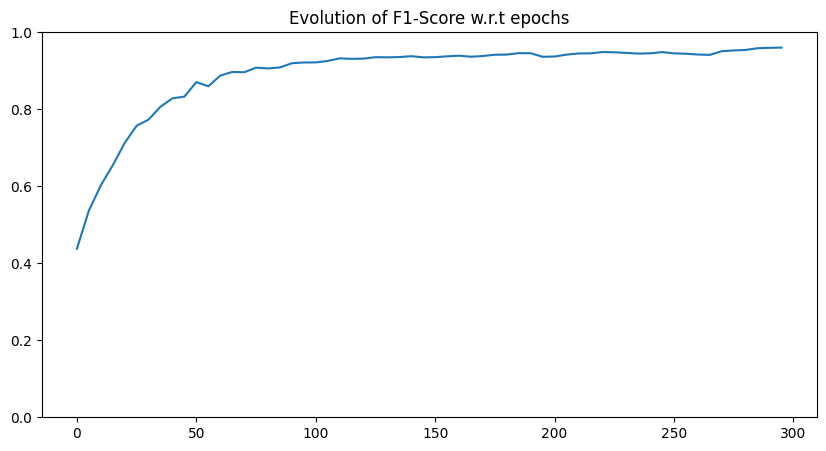

In [ ]:
### F1-SCORE ON VALID DATASET
score_valid = evaluate(student_model, loss_fcn, device, val_dataloader)
print("Basic Model : F1-Score on the validation set: {:.4f}".format(score_valid))


### PLOT EVOLUTION OF F1-SCORE W.R.T EPOCHS
def plot_f1_score(epoch_list, scores):
    plt.figure(figsize=[10, 5])
    plt.plot(epoch_list, scores)
    plt.title("Evolution of F1-Score w.r.t epochs")
    plt.ylim([0.0, 1.0])
    plt.show()


plot_f1_score(epoch_list, student_model_scores)

## Conv 2D as Message Passing Neural Network


## Introduction

The use of graph is a way to structure data by adding neighborhood information between features. This then allows to do operations on the data that are local to each node and its neighbors. This is the main idea behind Graph Neural Networks (GNNs). [`pytorch-geometric`](https://pytorch-geometric.readthedocs.io/en/latest/) is a library compatible with PyTorch that allows to easily implement GNNs. The most general structure is the [`MessagePassing`](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.MessagePassing.html#torch_geometric.nn.conv.MessagePassing) class that is then used as a base for more specific GNNs as seen in the course ([Graph Convolutional Networks](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html#torch_geometric.nn.conv.GCNConv) or [Graph AttenTion Convolution](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GATConv.html#torch_geometric.nn.conv.GATConv)).

On the other hand, you already know an operation that uses the structure of the data to do local operations: the convolution (https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). One can see the convolution as a specific case of the message passing neural network. The goal of this notebook is to show how to use the `MessagePassing` class to implement a convolutional neural network.
You will be asked to implement 3 functions. You should give back those three functions in a file named `conv_as_message_passing.py`. These functions will then be automatically tested. So be sure to respect the function signature and the function name.


## Assumptions

To make the implementation easier we will make some assumptions:
- the input is a single image (batch size of 1) of size 'C x H x W'
- the convolution will be a 3x3 kernel with stride 1 and padding 1.

You may also assume that the Conv2D layer has no bias but it will be slightly penalized in the grading.

Bonus points will be given if you can handle the cases that are not covered by those assumptions.


## Questions

### Question 2

> Using the formalism used in the [`MessagePassing`](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.MessagePassing.html#torch_geometric.nn.conv.MessagePassing) documentation (and on [wikipedia](https://en.wikipedia.org/wiki/Graph_neural_network#Message_passing_layers) with sligthly different notations), explain how theorically you can simulate a 2D convolution using the `MessagePassing` formalism. This may include a pre-processing step to transform the image into a graph and then a post-processing step to transform the graph back into an image. (:warning: Those steps should be independent of the parameters of the convolution, but not necessarily from the hyper-parameters.)
$$\mathbf{x}_{i}^{\prime} = \gamma_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\bigoplus\limits_{j \in \mathcal{N}(i)}\,\phi_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\mathbf{x}_{j},\mathbf{e}_{j,i} \right) \right),$$


HINT : It is possible to do it with the following $\gamma$ :

$$ \gamma_\Theta : x,y \mapsto y $$


**Answer:**

In order to implement this, one can convert the image to a graph in which every pixel is a node and with connectivity such that in this graph every node is conected to the nodes which would be involved in a convolution centered around that pixel.

One then adds to each edge $e_{ij}$ the information corresponding to the position of the pixel with respect to the target node $x_i$ (or center pixel). $\phi$ then takes this information to match the corresponding kernel value to the appropriate source node $x_j$ and multiplies them together. The aggregation function is then a sum.

We then use the $\gamma$ suggested in the hint.


In [ ]:
import torch
import torch_geometric
from torch_geometric.nn import radius_graph
from torch_geometric.data import Data


### Question 3

> Implement the pre-processing function, you can use the follwing code skeleton (you may change the output type, it is just a strong suggestion):

In [ ]:
def image_to_graph(
    image: torch.Tensor, conv2d: torch.nn.Conv2d | None = None
):#-> torch_geometric.data.Data:
    """
    Converts an image tensor to a PyTorch Geometric Data object.
    COMPLETE

    Arguments:
    ----------
    image : torch.Tensor
        Image tensor of shape (C, H, W).
    conv2d : torch.nn.Conv2d, optional
        Conv2d layer to simulate, by default None
        Is used to determine the size of the receptive field.

    Returns:
    --------
    torch_geometric.data.Data
        Graph representation of the image.
    """
    # Assumptions (remove it for the bonus)
    assert image.dim() == 3, f"Expected 3D tensor, got {image.dim()}D tensor."
    if conv2d is not None:
        assert conv2d.padding[0] == conv2d.padding[1] == 1, "Expected padding of 1 on both sides."
        assert conv2d.kernel_size[0] == conv2d.kernel_size[1] == 3, "Expected kernel size of 3x3."
        assert conv2d.stride[0] == conv2d.stride[1] == 1, "Expected stride of 1."

    c,h,w = image.shape
    kernel_size = conv2d.kernel_size[0]
#concatenate the width and length and have the features for each node be the values at a point (i,j) for all channels
    x = image.view(c,-1).T
# Create coordinates for each node
    coords = []
    for r_ in range(h):
        for col_ in range(w):
            coords.append([col_, -r_])  # (x, y)
    pos = torch.tensor(coords, dtype=torch.float)
    radius = (kernel_size - 1)//2
    # connect close neighbors
    edge_index = radius_graph(pos, r=radius+0.5)

    #each edge source --> targe has as attributes the coordinates of the the vector source - target to later match it with the kernel
    edge_attr = pos[edge_index[0]] - pos[edge_index[1]]

    #shift so that attributes correspond to indices
    def edge_attr_to_kernel_indices(edge_attr: torch.Tensor, kernel_size: int) -> torch.Tensor:
      """
      Converts edge attributes [x, y] from spatial coordinates (right, up)
      into kernel indices [row, col] suitable for indexing into a
      (kernel_size x kernel_size) tensor.
      """
      center = (kernel_size - 1) // 2
      x = edge_attr[:, 0]
      y = edge_attr[:, 1]
      row = center - y  # up → row decreases
      col = center + x  # right → col increases
      return torch.stack([row, col], dim=1).long()

    edge_attr = edge_attr_to_kernel_indices(edge_attr, kernel_size)

    #Add self-loops to the adjacency matrix and corresponding attributes
    def add_self_loops_with_attrs(edge_index, edge_attr, num_nodes, radius):
      # Add self-loop edges
      self_loops = torch.arange(num_nodes, dtype=torch.long)
      self_loop_edges = torch.stack([self_loops, self_loops], dim=0)  # shape [2, num_nodes]

      # Add matching self-loop attributes: center of the kernel
      self_loop_attrs = torch.full((num_nodes, 2), radius, dtype=torch.long)  # shape [num_nodes, 2]

      # Concatenate with existing edge_index and edge_attr
      edge_index = torch.cat([edge_index, self_loop_edges], dim=1)
      edge_attr = torch.cat([edge_attr, self_loop_attrs], dim=0)
      return edge_index, edge_attr

    edge_index, edge_attr = add_self_loops_with_attrs(edge_index, edge_attr, x.size(0), radius)

    #create graph object
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data

### Question 4

> Implement the post-processing function, you can use the follwing code skeleton:

In [ ]:
def graph_to_image(
    data: torch.Tensor, height: int, width: int, conv2d: torch.nn.Conv2d | None = None
) -> torch.Tensor:
    """
    Converts a graph representation of an image to an image tensor.

    Arguments:
    ----------
    data : torch.Tensor
        Graph data representation of the image.
    height : int
        Height of the image.
    width : int
        Width of the image.
    conv2d : torch.nn.Conv2d, optional
        Conv2d layer to simulate, by default None

    Returns:
    --------
    torch.Tensor
        Image tensor of shape (C, H, W).
    """
    # Assumptions (remove it for the bonus)
    assert data.dim() == 2, f"Expected 2D tensor, got {data.dim()}D tensor."
    if conv2d is not None:
        assert conv2d.padding[0] == conv2d.padding[1] == 1, "Expected padding of 1 on both sides."
        assert conv2d.kernel_size[0] == conv2d.kernel_size[1] == 3, "Expected kernel size of 3x3."
        assert conv2d.stride[0] == conv2d.stride[1] == 1, "Expected stride of 1."
    h,w = height,width
    _,c = data.shape #c = number of out_channels
    image = (data.T).reshape(c,h,w)
    return image

#### Recommended test cases

We **encourage** you to test that you have the property that the pre-processing function followed by the post-processing function is the identity function.

In [ ]:
ref_conv = torch.nn.Conv2d(5, 7, kernel_size=3, padding=1, stride=1)
image = torch.randn(5, 10, 11)
g_image = image_to_graph(image, ref_conv)
reconstructed_image = graph_to_image(g_image.x, 10, 11, ref_conv)
assert torch.allclose(image, reconstructed_image)

### Question 5

> Implement the `Conv2dMessagePassing` class that will simulate a 2D convolution using the `MessagePassing` formalism.
You should inherit from the `MessagePassing` class and only change the `__init__` and `message` functions (the `forward` function has already been changed for you). You should use the following code skeleton:

In [ ]:
class Conv2dMessagePassing(graphnn.MessagePassing):
    """
    A Message Passing layer that simulates a given Conv2d layer.
    """

    def __init__(self, conv2d: torch.nn.Conv2d):
        super().__init__(aggr = 'add')
        self.kernel_size = (conv2d.kernel_size)[0]
        self.in_channels = conv2d.in_channels
        self.out_channels = conv2d.out_channels
        kernel = conv2d.weight.data.clone()#kernel shape [out_c, in_c, kH, kW]

        # Register as a learnable parameter
        self.kernel = nn.Parameter(kernel)

    def forward(self, data):
        self.edge_index = data.edge_index
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return out

    def message(self, x_j: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        """
        Computes the message to be passed for each edge.
        For each edge e = (u, v) in the graph indexed by i,
        the message trough the edge e (ie from node u to node v)
        should be returned as the i-th line of the output tensor.
        (The message is phi(u, v, e) in the formalism.)
        To do this you can access the features of the source node
        in x_j[i] and the attributes of the edge in edge_attr[i].

        Arguments:
        ----------
        x_j : torch.Tensor
            The features of the source node for each edge (of size E x in_channels).
        edge_attr : torch.Tensor
            The attributes of the edge (of size E x edge_attr_dim).

        Returns:
        --------
        torch.Tensor
            The message to be passed for each edge (of size E x out_channels)
        """
        # The sum in the message is over the channels as we created a graph which combined all the channels into a single point.
        # The aggregate function will then sum over the source nodes for each target node.

        #invert shape to match kernel shape and add out_channel dimension
        x_j = x_j.T
        x_j = x_j.unsqueeze(0)

        #multiply the source nodes with associated kernel value
        kernel_values = self.kernel[:,:,edge_attr[:,0],edge_attr[:,1]]
        kernel_times_pixels_per_in_channel = kernel_values*x_j

        #sum over the input channels
        kernel_times_pixels = torch.sum(kernel_times_pixels_per_in_channel, axis = 1)

        #invert shape again to match expected x shape
        return kernel_times_pixels.T






## Test example

In [ ]:
#from conv_as_message_passing import image_to_graph, graph_to_image, Conv2dMessagePassing

c = 5
h = 10
w = 11

ref_conv = torch.nn.Conv2d(c, 2, kernel_size=3, padding=1, stride=1, bias=False)
image = torch.randn(c, h, w)

g_image = image_to_graph(image, ref_conv)
ref_conv.weight.data = torch.randn_like(ref_conv.weight.data)

conv_mp = Conv2dMessagePassing(ref_conv)
g_image = conv_mp(g_image)

y_th = ref_conv(image)

ref_conv.weight.data = torch.randn_like(ref_conv.weight.data)
reconstructed_image = graph_to_image(g_image, h, w, ref_conv)

assert torch.allclose(y_th, reconstructed_image, atol=1e-4)
